Import All Libraries

In [216]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score, classification_report, 
                            confusion_matrix,mean_absolute_error,precision_score, recall_score, 
                            f1_score, roc_auc_score, roc_curve,roc_auc_score, roc_curve, ConfusionMatrixDisplay)

Load Dataset

In [217]:
loan_df = pd.read_csv(r'C:\Users\parth\Desktop\week-2\week-2-ds\Loan_Modelling.csv')
loan_df.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


Initial Data Exploration

In [218]:
loan_df.shape

(5000, 14)

In [219]:
loan_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [220]:
loan_df.describe()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93169.257000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,1759.455086,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,90005.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [221]:
loan_df.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64

In [222]:
loan_df.duplicated().sum()

np.int64(0)

Part - 1 Regression Model

 Define Features and Target

In [223]:
# drop using the actual column name
loan_df = loan_df.drop(columns=['ID', 'ZIPCode'])

In [224]:
X_reg = loan_df.drop(columns=['CCAvg', 'Personal_Loan'])
y_reg = loan_df['CCAvg']

Train-Test Split

In [225]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=40)

Feature Scaling

In [226]:
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

Train Regression Model

In [227]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg_scaled, y_train_reg)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Regression Predictions

In [228]:
y_pred_test_reg = lin_reg.predict(X_test_reg_scaled)

y_pred_train_reg = lin_reg.predict(X_train_reg_scaled)

Regression Evalution

Test metrics

In [229]:
test_mean = mean_squared_error(y_test_reg, y_pred_test_reg)
test_r2 = r2_score(y_test_reg, y_pred_test_reg)
test_rmse = np.sqrt(test_mean)
print("Mean Squared Error:", test_mean)
print("R-squared:", test_r2) 
print("Root Mean Squared Error:", test_rmse)

Mean Squared Error: 1.6425994496697816
R-squared: 0.41271562449612875
Root Mean Squared Error: 1.2816393602218143


Train Metrics

In [230]:
train_mean = mean_squared_error(y_train_reg, y_pred_train_reg)
train_r2 = r2_score(y_train_reg, y_pred_train_reg)
train_rmse = np.sqrt(train_mean)
print("Mean Squared Error:", train_mean)
print("R-squared:", train_r2) 
print("Root Mean Squared Error:", train_rmse)

Mean Squared Error: 1.823371879228974
R-squared: 0.4233615800390115
Root Mean Squared Error: 1.3503228796213793


Regression Coefficient Interpretation

In [231]:
coefficients = pd.DataFrame({
    'Feature': X_reg.columns,
    'Coefficient': lin_reg.coef_
})
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)

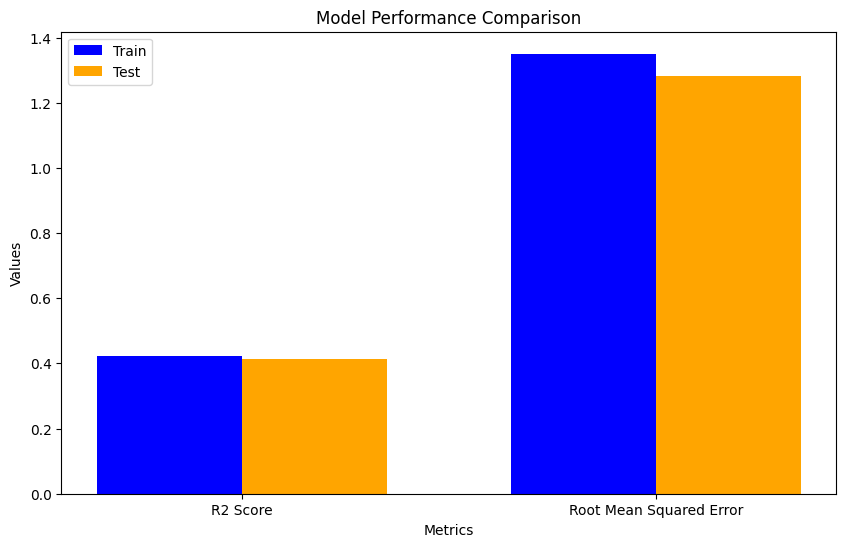

In [232]:
metrics = ['R2 Score', 'Root Mean Squared Error']
train_values = [train_r2, train_rmse]
test_values = [test_r2, test_rmse]
x = np.arange(len(metrics))
width = 0.35
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, train_values, width, label='Train', color='blue')
plt.bar(x + width/2, test_values, width, label='Test', color='orange')
plt.xlabel('Metrics') 
plt.ylabel('Values')
plt.title('Model Performance Comparison')
plt.xticks(x, metrics)
plt.legend()
plt.show()

In [233]:
X_reg_scaled_full = scaler_reg.fit_transform(X_reg)
lin_reg.fit(X_reg_scaled_full, y_reg)
loan_df['CCAvg_Predicted'] = lin_reg.predict(X_reg_scaled_full)

In [234]:
loan_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Income              5000 non-null   int64  
 3   Family              5000 non-null   int64  
 4   CCAvg               5000 non-null   float64
 5   Education           5000 non-null   int64  
 6   Mortgage            5000 non-null   int64  
 7   Personal_Loan       5000 non-null   int64  
 8   Securities_Account  5000 non-null   int64  
 9   CD_Account          5000 non-null   int64  
 10  Online              5000 non-null   int64  
 11  CreditCard          5000 non-null   int64  
 12  CCAvg_Predicted     5000 non-null   float64
dtypes: float64(2), int64(11)
memory usage: 507.9 KB


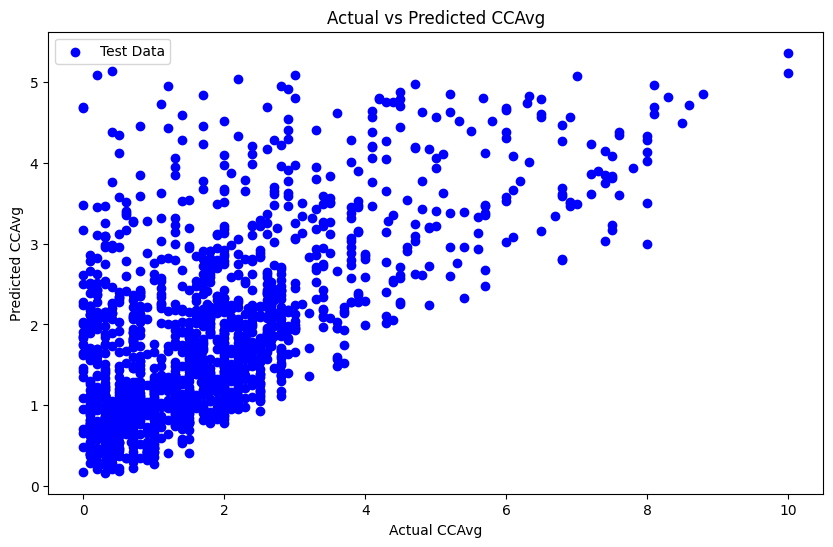

In [235]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred_test_reg, color='blue', label='Test Data')
plt.xlabel('Actual CCAvg')
plt.ylabel('Predicted CCAvg')
plt.title('Actual vs Predicted CCAvg')
plt.legend()
plt.show()

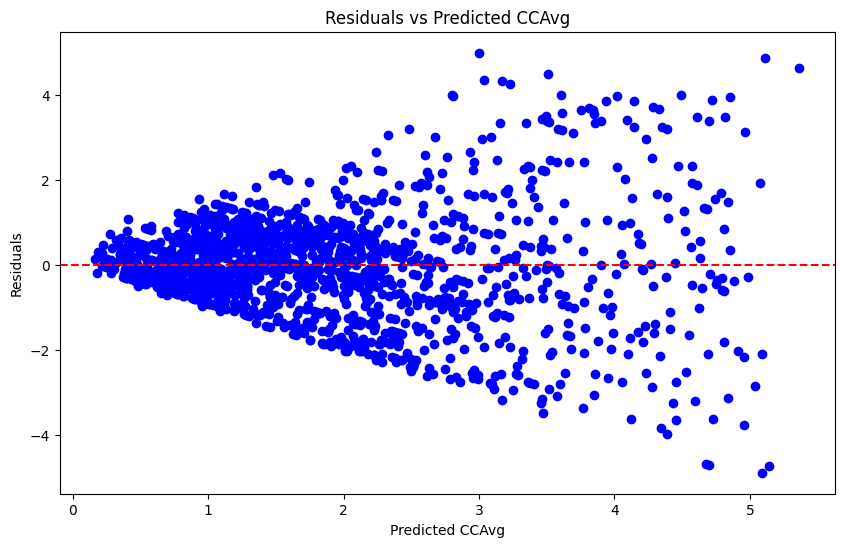

In [236]:
residuals = y_test_reg - y_pred_test_reg
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test_reg, residuals, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted CCAvg')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted CCAvg')
plt.show()

Part B - Classification Model

Logistic Regression

In [237]:
X_clf = loan_df.drop(columns=['CCAvg', 'Personal_Loan'])
y_clf = loan_df['Personal_Loan']

Train - test split

In [238]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.3, random_state=40, stratify=y_clf)

Feature Scaling

In [239]:
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

Train Classification Model

In [240]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_clf_scaled, y_train_clf)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Classification Predictions

In [241]:
y_pred_test_clf = log_model.predict(X_test_clf_scaled)
y_pred_train_clf = log_model.predict(X_train_clf_scaled)
y_pred_test_proba_clf = log_model.predict_proba(X_test_clf_scaled)[:, 1]
y_pred_train_proba_clf = log_model.predict_proba(X_train_clf_scaled)[:, 1]

Test Confusion Matrix

Confusion Matrix:
 TN - correctly predicted negatives (predicted as 0, actual as 0): 1338
 FP - incorrectly predicted positives (predicted as 1, actual as 0): 18
 FN - incorrectly predicted negatives (predicted as 0, actual as 1): 50
 TP - correctly predicted positives (predicted as 1, actual as 1): 94


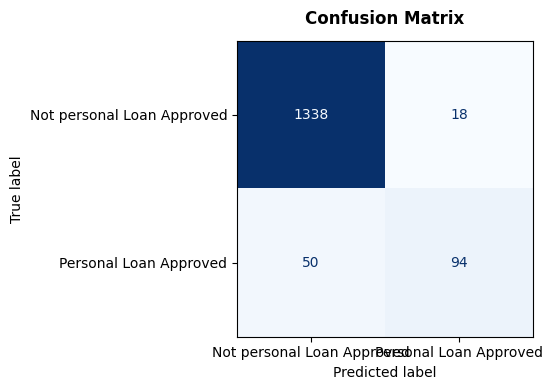

In [242]:
cm = confusion_matrix(y_test_clf, y_pred_test_clf)
tn, fp, fn, tp = cm.ravel()
print("Confusion Matrix:")
print(f' TN - correctly predicted negatives (predicted as 0, actual as 0): {tn}')
print(f' FP - incorrectly predicted positives (predicted as 1, actual as 0): {fp}')
print(f' FN - incorrectly predicted negatives (predicted as 0, actual as 1): {fn}')
print(f' TP - correctly predicted positives (predicted as 1, actual as 1): {tp}')
fig, ax = plt.subplots(figsize=(6, 4))
display = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                 display_labels=['Not personal Loan Approved', 'Personal Loan Approved'])
display.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
ax.set_title('Confusion Matrix',fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


Train Confusion Matrix

Training Confusion Matrix:
 TN - correctly predicted negatives (predicted as 0, actual as 0): 3116
 FP - incorrectly predicted positives (predicted as 1, actual as 0): 48
 FN - incorrectly predicted negatives (predicted as 0, actual as 1): 127
 TP - correctly predicted positives (predicted as 1, actual as 1): 209


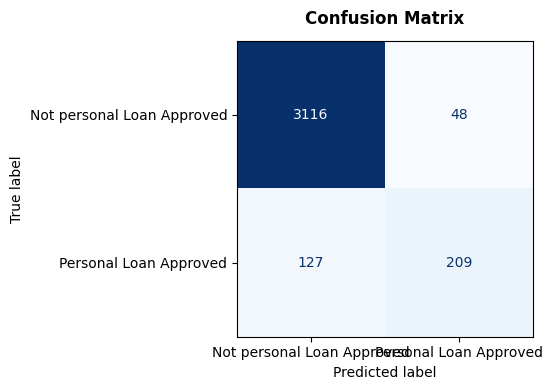

In [243]:
cm_train = confusion_matrix(y_train_clf, y_pred_train_clf)
tn_train, fp_train, fn_train, tp_train = cm_train.ravel()
print("Training Confusion Matrix:")
print(f' TN - correctly predicted negatives (predicted as 0, actual as 0): {tn_train}')
print(f' FP - incorrectly predicted positives (predicted as 1, actual as 0): {fp_train}')
print(f' FN - incorrectly predicted negatives (predicted as 0, actual as 1): {fn_train}')
print(f' TP - correctly predicted positives (predicted as 1, actual as 1): {tp_train}')
fig, ax = plt.subplots(figsize=(6, 4))
display = ConfusionMatrixDisplay(confusion_matrix=cm_train, 
                                 display_labels=['Not personal Loan Approved', 'Personal Loan Approved'])
display.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
ax.set_title('Confusion Matrix',fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

Calculate Train and Test Metrics

In [244]:
train_accuracy = accuracy_score(y_train_clf, y_pred_train_clf)
test_accuracy = accuracy_score(y_test_clf, y_pred_test_clf)
train_precision = precision_score(y_train_clf, y_pred_train_clf)
test_precision = precision_score(y_test_clf, y_pred_test_clf)
train_recall = recall_score(y_train_clf, y_pred_train_clf)
test_recall = recall_score(y_test_clf, y_pred_test_clf)
train_f1 = f1_score(y_train_clf, y_pred_train_clf)
test_f1 = f1_score(y_test_clf, y_pred_test_clf)
test_auc = roc_auc_score(y_test_clf, y_pred_test_proba_clf)
train_auc = roc_auc_score(y_train_clf, y_pred_train_proba_clf)

print("======== Training Metrics ========")
print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Training Precision: {train_precision:.2f}")
print(f"Training Recall: {train_recall:.2f}")
print(f"Training F1-Score: {train_f1:.2f}")
print(f"Training AUC-ROC: {train_auc:.2f}")

print("\n======== Testing Metrics ========")
print(f"Testing Accuracy: {test_accuracy:.2f}")
print(f"Testing Precision: {test_precision:.2f}")
print(f"Testing Recall: {test_recall:.2f}")
print(f"Testing F1-Score: {test_f1:.2f}")
print(f"Testing AUC-ROC: {test_auc:.2f}")

======== Training Metrics ========
Training Accuracy: 0.95
Training Precision: 0.81
Training Recall: 0.62
Training F1-Score: 0.70
Training AUC-ROC: 0.96

======== Testing Metrics ========
Testing Accuracy: 0.95
Testing Precision: 0.84
Testing Recall: 0.65
Testing F1-Score: 0.73
Testing AUC-ROC: 0.95


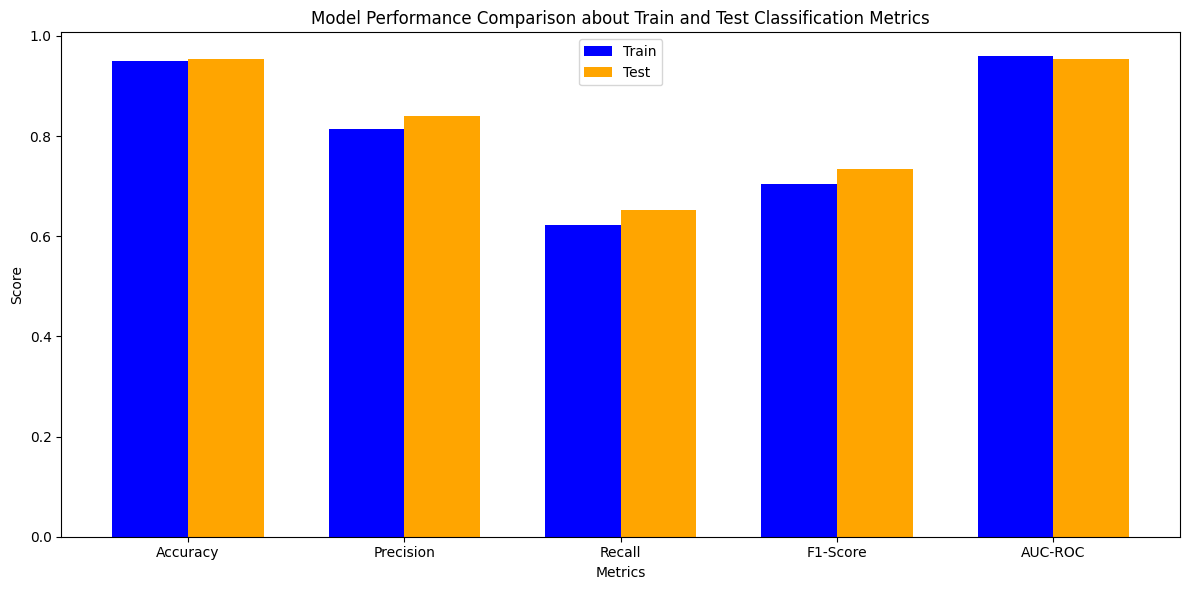

In [245]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
train_values = [train_accuracy, train_precision, train_recall, train_f1, train_auc]
test_values = [test_accuracy, test_precision, test_recall, test_f1, test_auc]
x = np.arange(len(metrics))
width = 0.35
plt.figure(figsize=(12, 6))
plt.bar(x - width/2, train_values, width, label='Train', color='blue')
plt.bar(x + width/2, test_values, width, label='Test', color='orange')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison about Train and Test Classification Metrics')
plt.xticks(x, metrics)
plt.legend()
plt.tight_layout()
plt.show()

ROC Curve & AUC Test

C:\Users\parth\AppData\Local\Temp\ipykernel_32728\2728792511.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([0, 1], [0, 1],'k--', color='red', lw=2, label='Random Classifier')


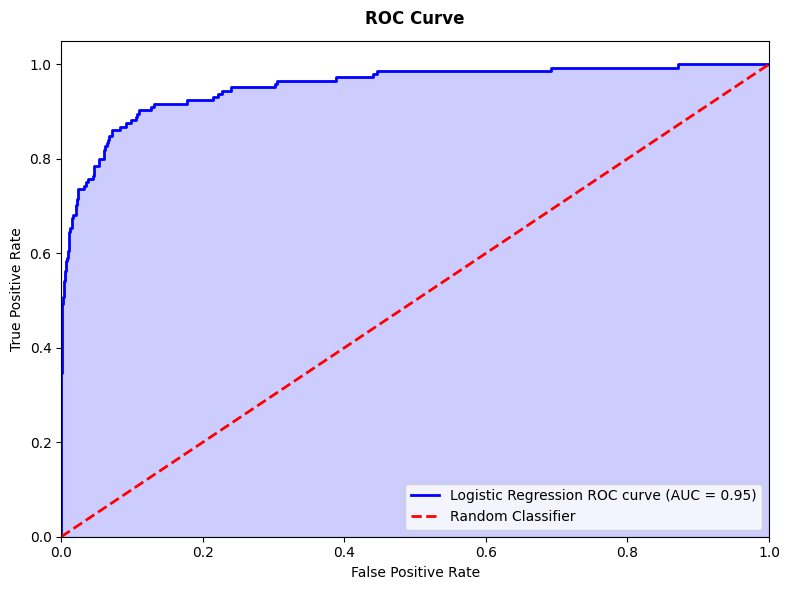

In [246]:
fpr, tpr, thresholds = roc_curve(y_test_clf, y_pred_test_proba_clf)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='blue', lw=2,label=f'Logistic Regression ROC curve (AUC = {test_auc:.2f})')
ax.plot([0, 1], [0, 1],'k--', color='red', lw=2, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.2, color='blue')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve',fontweight='bold', pad=12)
ax.legend(loc='lower right')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

ROC Curve & AUC Train

C:\Users\parth\AppData\Local\Temp\ipykernel_32728\146750156.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([0, 1], [0, 1],'k--', color='red', lw=2, label='Random Classifier')


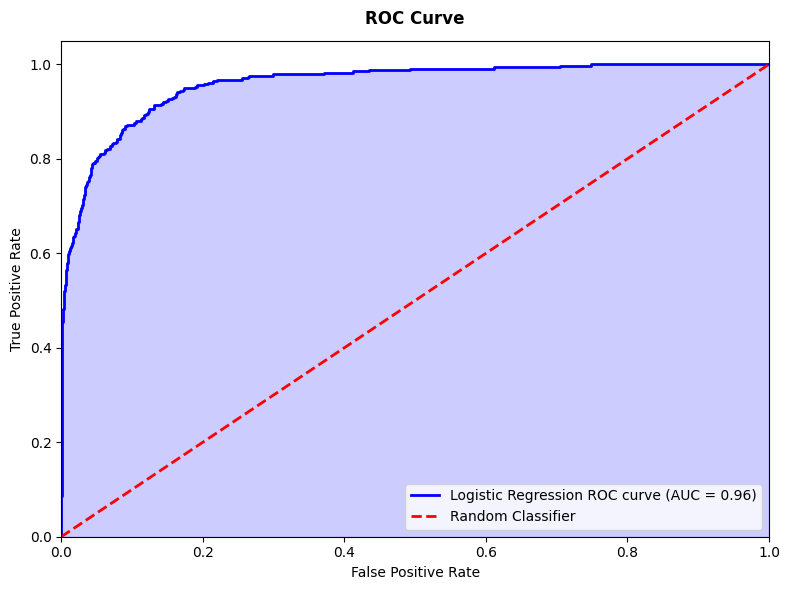

In [247]:
fpr, tpr, thresholds = roc_curve(y_train_clf, y_pred_train_proba_clf)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='blue', lw=2,label=f'Logistic Regression ROC curve (AUC = {train_auc:.2f})')
ax.plot([0, 1], [0, 1],'k--', color='red', lw=2, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.2, color='blue')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve',fontweight='bold', pad=12)
ax.legend(loc='lower right')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

Precision VS Recall - Threshold Tuning

 Threshold |   Accuracy |  Precision |     Recall |   F1-Score
--------------------------------------------------------------
      0.30 |       0.95 |       0.72 |       0.74 |       0.73 
      0.40 |       0.95 |       0.79 |       0.68 |       0.73 
      0.50 |       0.95 |       0.84 |       0.65 |       0.73  <-- Default
      0.60 |       0.95 |       0.89 |       0.59 |       0.71 
      0.70 |       0.95 |       0.94 |       0.51 |       0.66 


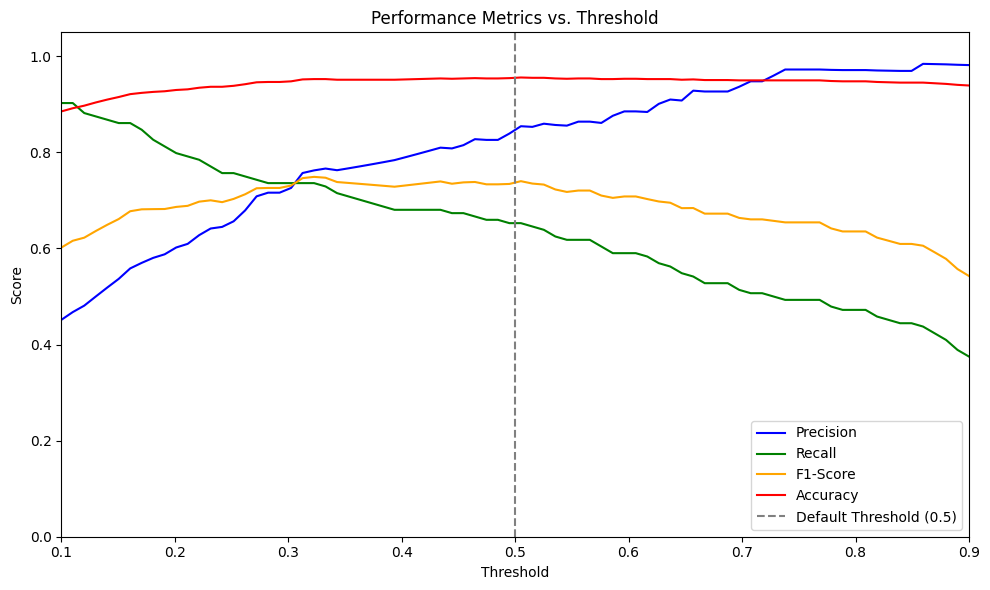

In [248]:
thresholds_to_try = [0.3,0.4,0.5,0.6,0.7]
print(f"{'Threshold':>10} | {'Accuracy':>10} | {'Precision':>10} | {'Recall':>10} | {'F1-Score':>10}")
print("-" * 62)
for threshold in thresholds_to_try:
    y_pred_threshold = (y_pred_test_proba_clf >= threshold).astype(int)
    acc = accuracy_score(y_test_clf, y_pred_threshold)
    prec = precision_score(y_test_clf, y_pred_threshold)
    rec = recall_score(y_test_clf, y_pred_threshold)
    f1 = f1_score(y_test_clf, y_pred_threshold)
    marker = " <-- Default" if threshold == 0.5 else ""
    print(f"{threshold:>10.2f} | {acc:>10.2f} | {prec:>10.2f} | {rec:>10.2f} | {f1:>10.2f} {marker}")
thresh_range = np.linspace(0.1, 0.9, 80)
precisions, recalls, f1s, accuracies = [], [], [], []
for thresh in thresh_range:
    y_pred_thresh = (y_pred_test_proba_clf >= thresh).astype(int)
    precisions.append(precision_score(y_test_clf, y_pred_thresh))
    recalls.append(recall_score(y_test_clf, y_pred_thresh))
    f1s.append(f1_score(y_test_clf, y_pred_thresh))
    accuracies.append(accuracy_score(y_test_clf, y_pred_thresh))
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresh_range, precisions, label='Precision', color='blue')
ax.plot(thresh_range, recalls, label='Recall', color='green')
ax.plot(thresh_range, f1s, label='F1-Score', color='orange')
ax.plot(thresh_range, accuracies, label='Accuracy', color='red')
ax.axvline(x=0.5, color='gray', linestyle='--', label='Default Threshold (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Performance Metrics vs. Threshold')
ax.legend(loc='lower right')
ax.set_xlim([0.1, 0.9])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

 Threshold |   Accuracy |  Precision |     Recall |   F1-Score
--------------------------------------------------------------
      0.30 |       0.94 |       0.68 |       0.74 |       0.71 
      0.40 |       0.95 |       0.74 |       0.68 |       0.71 
      0.50 |       0.95 |       0.81 |       0.62 |       0.70  <-- Default
      0.60 |       0.95 |       0.88 |       0.57 |       0.69 
      0.70 |       0.95 |       0.94 |       0.49 |       0.64 


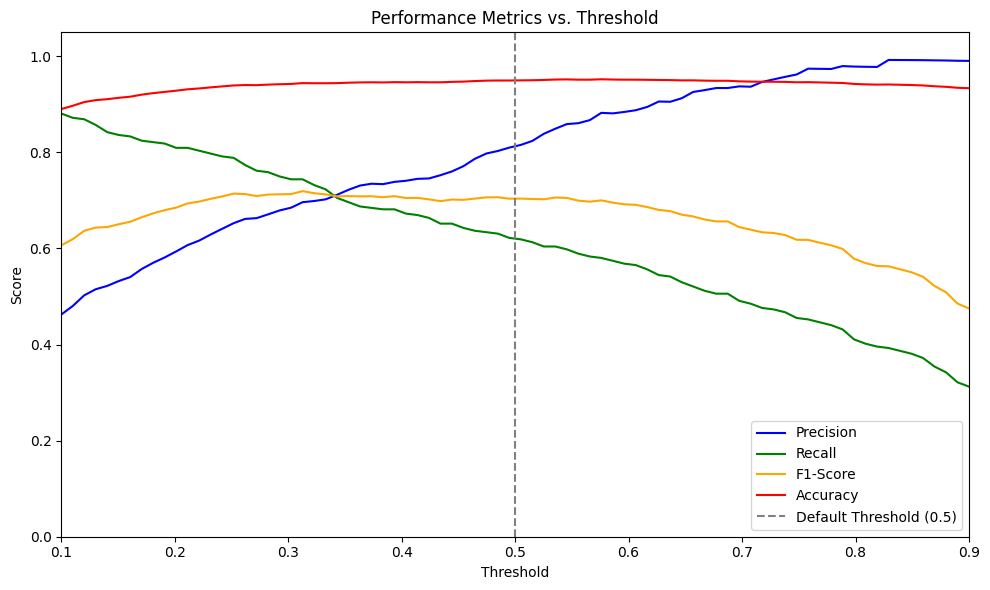

In [249]:
train_thresholds_to_try = [0.3,0.4,0.5,0.6,0.7]
print(f"{'Threshold':>10} | {'Accuracy':>10} | {'Precision':>10} | {'Recall':>10} | {'F1-Score':>10}")
print("-" * 62)
for threshold in train_thresholds_to_try:
    y_pred_threshold_train = (y_pred_train_proba_clf >= threshold).astype(int)
    acc_train = accuracy_score(y_train_clf, y_pred_threshold_train)
    prec_train = precision_score(y_train_clf, y_pred_threshold_train)
    rec_train = recall_score(y_train_clf, y_pred_threshold_train)
    f1_train = f1_score(y_train_clf, y_pred_threshold_train)
    marker = " <-- Default" if threshold == 0.5 else ""
    print(f"{threshold:>10.2f} | {acc_train:>10.2f} | {prec_train:>10.2f} | {rec_train:>10.2f} | {f1_train:>10.2f} {marker}")
thresh_range_train = np.linspace(0.1, 0.9, 80)
precisions_train, recalls_train, f1s_train, accuracies_train = [], [], [], []
for thresh in thresh_range_train:
    y_pred_thresh_train = (y_pred_train_proba_clf >= thresh).astype(int)
    precisions_train.append(precision_score(y_train_clf, y_pred_thresh_train))
    recalls_train.append(recall_score(y_train_clf, y_pred_thresh_train))
    f1s_train.append(f1_score(y_train_clf, y_pred_thresh_train))
    accuracies_train.append(accuracy_score(y_train_clf, y_pred_thresh_train))
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresh_range_train, precisions_train, label='Precision', color='blue')
ax.plot(thresh_range_train, recalls_train, label='Recall', color='green')
ax.plot(thresh_range_train, f1s_train, label='F1-Score', color='orange')
ax.plot(thresh_range_train, accuracies_train, label='Accuracy', color='red')
ax.axvline(x=0.5, color='gray', linestyle='--', label='Default Threshold (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Performance Metrics vs. Threshold')
ax.legend(loc='lower right')
ax.set_xlim([0.1, 0.9])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

           Feature  Coefficient
            Income     1.764076
         Education     1.431303
        CD_Account     0.879688
   CCAvg_Predicted     0.861743
            Family     0.851436
        Experience     0.838467
          Mortgage     0.059299
            Online    -0.283455
Securities_Account    -0.379170
        CreditCard    -0.424232
               Age    -0.617181


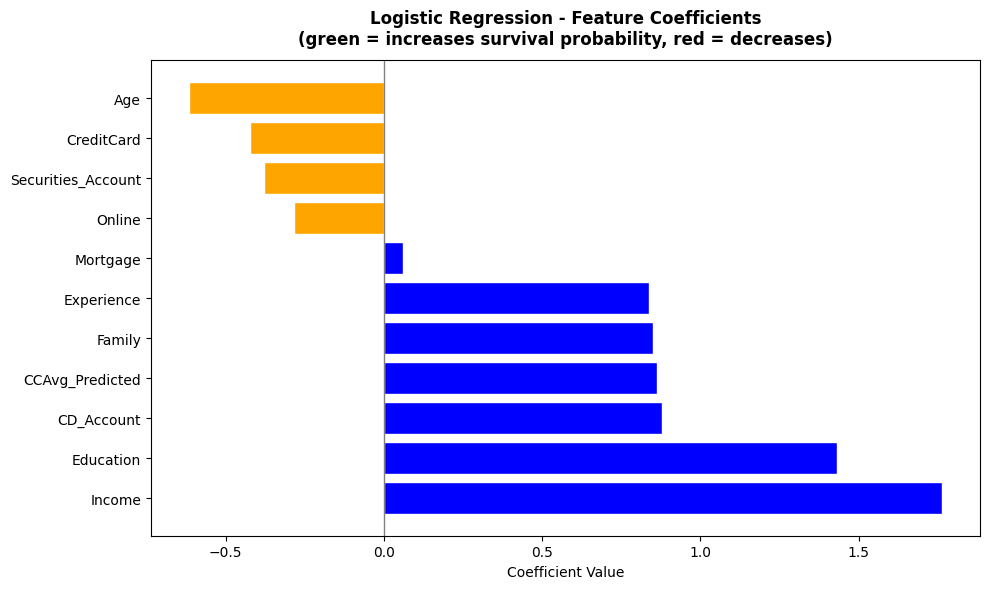

In [250]:
coef_df = pd.DataFrame({
    'Feature': X_clf.columns,
    'Coefficient': log_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)
print(coef_df.to_string(index=False))
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['blue' if coef > 0 else 'orange' for coef in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(x=0, color='gray', lw=1)
ax.set_xlabel('Coefficient Value')
ax.set_title('Logistic Regression - Feature Coefficients\n''(green = increases survival probability, red = decreases)',fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

Naive Bayes

In [251]:
navie_bayes_model = GaussianNB()
navie_bayes_model.fit(X_train_clf_scaled, y_train_clf)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


Classification Predictions

In [252]:
y_pred_test_clf = navie_bayes_model.predict(X_test_clf_scaled)
y_pred_train_clf = navie_bayes_model.predict(X_train_clf_scaled)
y_pred_test_proba_clf = navie_bayes_model.predict_proba(X_test_clf_scaled)[:, 1]
y_pred_train_proba_clf = navie_bayes_model.predict_proba(X_train_clf_scaled)[:, 1]

Test Confusion Matrix

Confusion Matrix:
 TN - correctly predicted negatives (predicted as 0, actual as 0): 1248
 FP - incorrectly predicted positives (predicted as 1, actual as 0): 108
 FN - incorrectly predicted negatives (predicted as 0, actual as 1): 44
 TP - correctly predicted positives (predicted as 1, actual as 1): 100


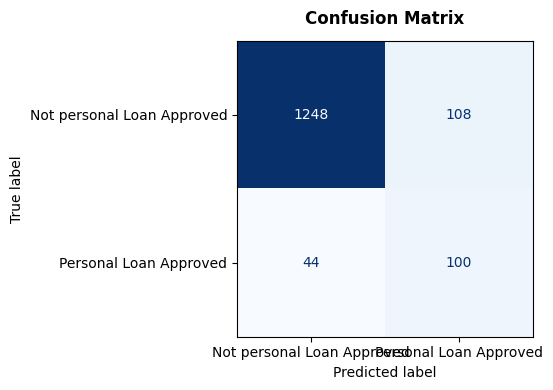

In [253]:
cm = confusion_matrix(y_test_clf, y_pred_test_clf)
tn, fp, fn, tp = cm.ravel()
print("Confusion Matrix:")
print(f' TN - correctly predicted negatives (predicted as 0, actual as 0): {tn}')
print(f' FP - incorrectly predicted positives (predicted as 1, actual as 0): {fp}')
print(f' FN - incorrectly predicted negatives (predicted as 0, actual as 1): {fn}')
print(f' TP - correctly predicted positives (predicted as 1, actual as 1): {tp}')
fig, ax = plt.subplots(figsize=(6, 4))
display = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                 display_labels=['Not personal Loan Approved', 'Personal Loan Approved'])
display.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
ax.set_title('Confusion Matrix',fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


Train Confusion Matrix

Training Confusion Matrix:
 TN - correctly predicted negatives (predicted as 0, actual as 0): 2903
 FP - incorrectly predicted positives (predicted as 1, actual as 0): 261
 FN - incorrectly predicted negatives (predicted as 0, actual as 1): 108
 TP - correctly predicted positives (predicted as 1, actual as 1): 228


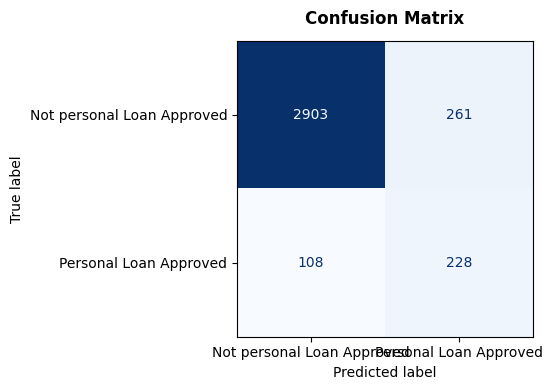

In [254]:
cm_train = confusion_matrix(y_train_clf, y_pred_train_clf)
tn_train, fp_train, fn_train, tp_train = cm_train.ravel()
print("Training Confusion Matrix:")
print(f' TN - correctly predicted negatives (predicted as 0, actual as 0): {tn_train}')
print(f' FP - incorrectly predicted positives (predicted as 1, actual as 0): {fp_train}')
print(f' FN - incorrectly predicted negatives (predicted as 0, actual as 1): {fn_train}')
print(f' TP - correctly predicted positives (predicted as 1, actual as 1): {tp_train}')
fig, ax = plt.subplots(figsize=(6, 4))
display = ConfusionMatrixDisplay(confusion_matrix=cm_train, 
                                 display_labels=['Not personal Loan Approved', 'Personal Loan Approved'])
display.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
ax.set_title('Confusion Matrix',fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

Calculate Train and Test Metrics

In [255]:
train_accuracy = accuracy_score(y_train_clf, y_pred_train_clf)
test_accuracy = accuracy_score(y_test_clf, y_pred_test_clf)
train_precision = precision_score(y_train_clf, y_pred_train_clf)
test_precision = precision_score(y_test_clf, y_pred_test_clf)
train_recall = recall_score(y_train_clf, y_pred_train_clf)
test_recall = recall_score(y_test_clf, y_pred_test_clf)
train_f1 = f1_score(y_train_clf, y_pred_train_clf)
test_f1 = f1_score(y_test_clf, y_pred_test_clf)
test_auc = roc_auc_score(y_test_clf, y_pred_test_proba_clf)
train_auc = roc_auc_score(y_train_clf, y_pred_train_proba_clf)

print("======== Training Metrics ========")
print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Training Precision: {train_precision:.2f}")
print(f"Training Recall: {train_recall:.2f}")
print(f"Training F1-Score: {train_f1:.2f}")
print(f"Training AUC-ROC: {train_auc:.2f}")

print("\n======== Testing Metrics ========")
print(f"Testing Accuracy: {test_accuracy:.2f}")
print(f"Testing Precision: {test_precision:.2f}")
print(f"Testing Recall: {test_recall:.2f}")
print(f"Testing F1-Score: {test_f1:.2f}")
print(f"Testing AUC-ROC: {test_auc:.2f}")

======== Training Metrics ========
Training Accuracy: 0.89
Training Precision: 0.47
Training Recall: 0.68
Training F1-Score: 0.55
Training AUC-ROC: 0.93

======== Testing Metrics ========
Testing Accuracy: 0.90
Testing Precision: 0.48
Testing Recall: 0.69
Testing F1-Score: 0.57
Testing AUC-ROC: 0.94


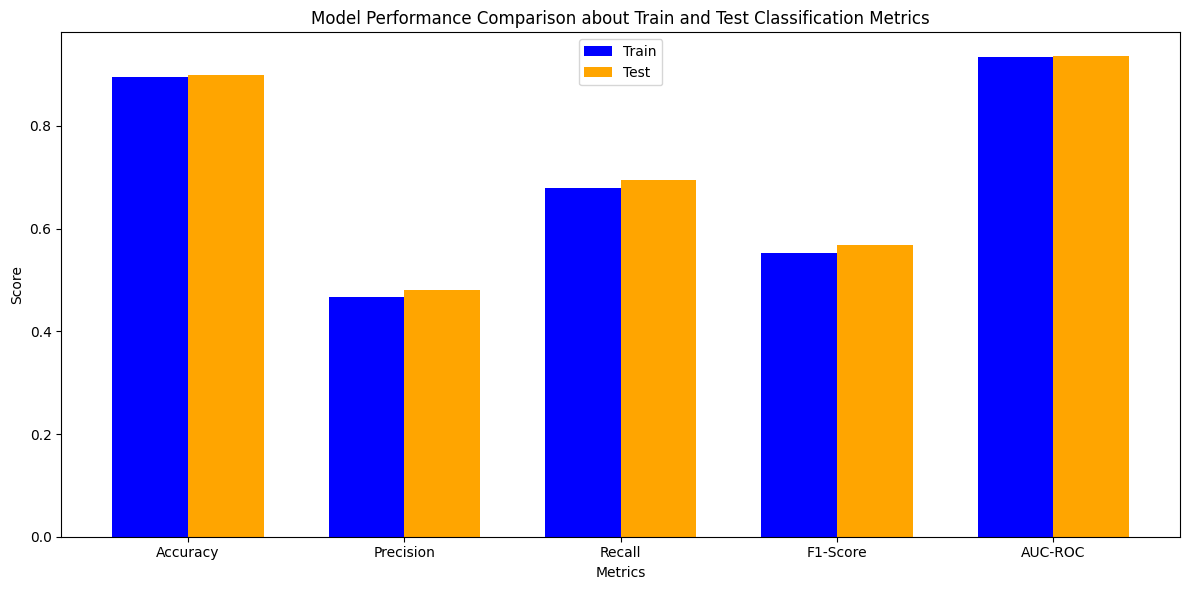

In [256]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
train_values = [train_accuracy, train_precision, train_recall, train_f1, train_auc]
test_values = [test_accuracy, test_precision, test_recall, test_f1, test_auc]
x = np.arange(len(metrics))
width = 0.35
plt.figure(figsize=(12, 6))
plt.bar(x - width/2, train_values, width, label='Train', color='blue')
plt.bar(x + width/2, test_values, width, label='Test', color='orange')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison about Train and Test Classification Metrics')
plt.xticks(x, metrics)
plt.legend()
plt.tight_layout()
plt.show()

ROC Curve & AUC Test

C:\Users\parth\AppData\Local\Temp\ipykernel_32728\2288230320.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([0, 1], [0, 1],'k--', color='red', lw=2, label='Random Classifier')


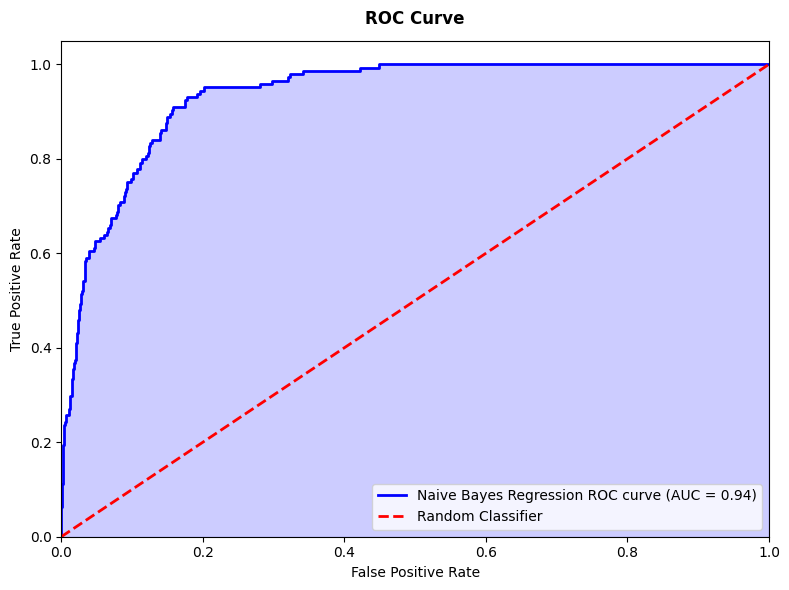

In [257]:
fpr, tpr, thresholds = roc_curve(y_test_clf, y_pred_test_proba_clf)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='blue', lw=2,label=f'Naive Bayes Regression ROC curve (AUC = {test_auc:.2f})')
ax.plot([0, 1], [0, 1],'k--', color='red', lw=2, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.2, color='blue')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve',fontweight='bold', pad=12)
ax.legend(loc='lower right')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

ROC Curve & AUC Train

C:\Users\parth\AppData\Local\Temp\ipykernel_32728\685447252.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([0, 1], [0, 1],'k--', color='red', lw=2, label='Random Classifier')


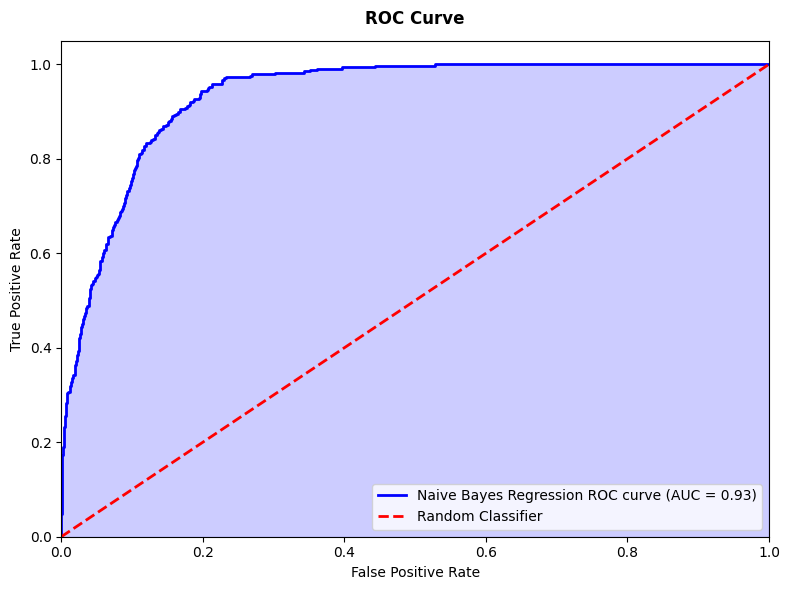

In [258]:
fpr, tpr, thresholds = roc_curve(y_train_clf, y_pred_train_proba_clf)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='blue', lw=2,label=f'Naive Bayes Regression ROC curve (AUC = {train_auc:.2f})')
ax.plot([0, 1], [0, 1],'k--', color='red', lw=2, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.2, color='blue')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve',fontweight='bold', pad=12)
ax.legend(loc='lower right')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

Precision VS Recall - Threshold Tuning

 Threshold |   Accuracy |  Precision |     Recall |   F1-Score
--------------------------------------------------------------
      0.30 |       0.89 |       0.44 |       0.76 |       0.56 
      0.40 |       0.89 |       0.46 |       0.72 |       0.56 
      0.50 |       0.90 |       0.48 |       0.69 |       0.57  <-- Default
      0.60 |       0.90 |       0.50 |       0.66 |       0.57 
      0.70 |       0.91 |       0.52 |       0.64 |       0.57 


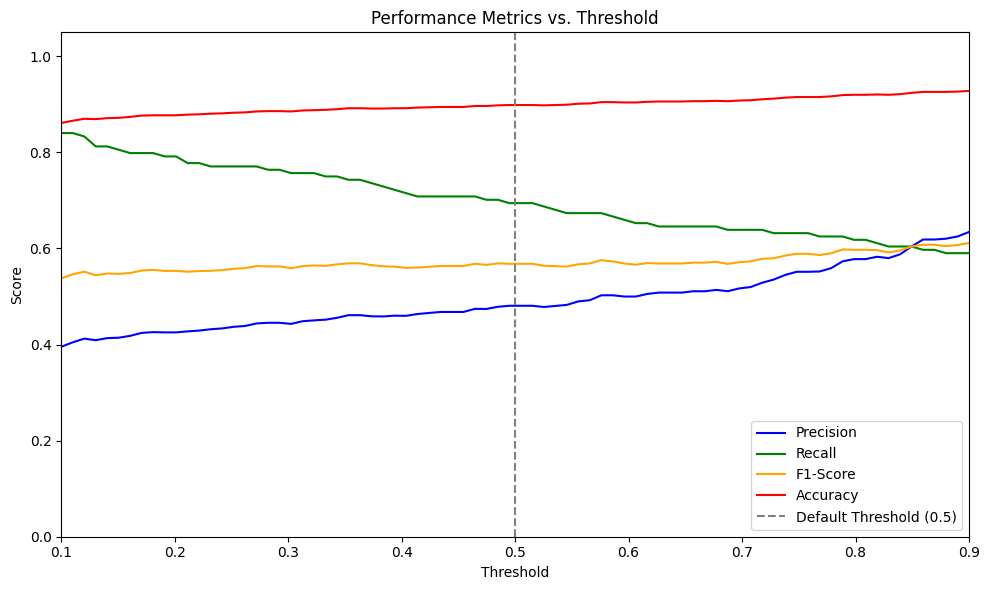

In [259]:
thresholds_to_try = [0.3,0.4,0.5,0.6,0.7]
print(f"{'Threshold':>10} | {'Accuracy':>10} | {'Precision':>10} | {'Recall':>10} | {'F1-Score':>10}")
print("-" * 62)
for threshold in thresholds_to_try:
    y_pred_threshold = (y_pred_test_proba_clf >= threshold).astype(int)
    acc = accuracy_score(y_test_clf, y_pred_threshold)
    prec = precision_score(y_test_clf, y_pred_threshold)
    rec = recall_score(y_test_clf, y_pred_threshold)
    f1 = f1_score(y_test_clf, y_pred_threshold)
    marker = " <-- Default" if threshold == 0.5 else ""
    print(f"{threshold:>10.2f} | {acc:>10.2f} | {prec:>10.2f} | {rec:>10.2f} | {f1:>10.2f} {marker}")
thresh_range = np.linspace(0.1, 0.9, 80)
precisions, recalls, f1s, accuracies = [], [], [], []
for thresh in thresh_range:
    y_pred_thresh = (y_pred_test_proba_clf >= thresh).astype(int)
    precisions.append(precision_score(y_test_clf, y_pred_thresh))
    recalls.append(recall_score(y_test_clf, y_pred_thresh))
    f1s.append(f1_score(y_test_clf, y_pred_thresh))
    accuracies.append(accuracy_score(y_test_clf, y_pred_thresh))
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresh_range, precisions, label='Precision', color='blue')
ax.plot(thresh_range, recalls, label='Recall', color='green')
ax.plot(thresh_range, f1s, label='F1-Score', color='orange')
ax.plot(thresh_range, accuracies, label='Accuracy', color='red')
ax.axvline(x=0.5, color='gray', linestyle='--', label='Default Threshold (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Performance Metrics vs. Threshold')
ax.legend(loc='lower right')
ax.set_xlim([0.1, 0.9])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

Precision VS Recall - Threshold Tuning -Train

 Threshold |   Accuracy |  Precision |     Recall |   F1-Score
--------------------------------------------------------------
      0.30 |       0.89 |       0.44 |       0.76 |       0.56 
      0.40 |       0.89 |       0.45 |       0.71 |       0.55 
      0.50 |       0.89 |       0.47 |       0.68 |       0.55  <-- Default
      0.60 |       0.90 |       0.48 |       0.66 |       0.56 
      0.70 |       0.90 |       0.50 |       0.63 |       0.56 


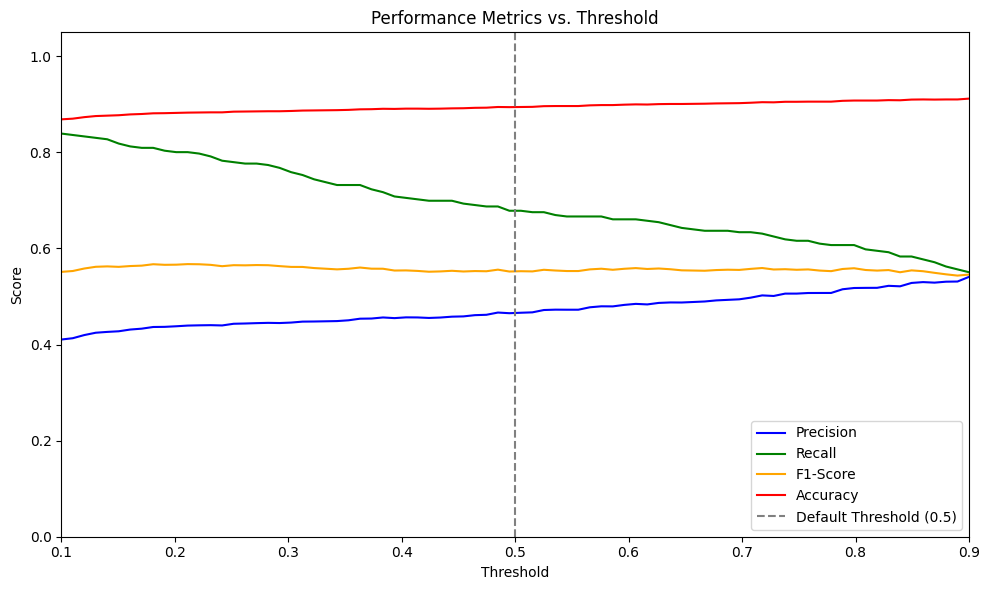

In [260]:
train_thresholds_to_try = [0.3,0.4,0.5,0.6,0.7]
print(f"{'Threshold':>10} | {'Accuracy':>10} | {'Precision':>10} | {'Recall':>10} | {'F1-Score':>10}")
print("-" * 62)
for threshold in train_thresholds_to_try:
    y_pred_threshold_train = (y_pred_train_proba_clf >= threshold).astype(int)
    acc_train = accuracy_score(y_train_clf, y_pred_threshold_train)
    prec_train = precision_score(y_train_clf, y_pred_threshold_train)
    rec_train = recall_score(y_train_clf, y_pred_threshold_train)
    f1_train = f1_score(y_train_clf, y_pred_threshold_train)
    marker = " <-- Default" if threshold == 0.5 else ""
    print(f"{threshold:>10.2f} | {acc_train:>10.2f} | {prec_train:>10.2f} | {rec_train:>10.2f} | {f1_train:>10.2f} {marker}")
thresh_range_train = np.linspace(0.1, 0.9, 80)
precisions_train, recalls_train, f1s_train, accuracies_train = [], [], [], []
for thresh in thresh_range_train:
    y_pred_thresh_train = (y_pred_train_proba_clf >= thresh).astype(int)
    precisions_train.append(precision_score(y_train_clf, y_pred_thresh_train))
    recalls_train.append(recall_score(y_train_clf, y_pred_thresh_train))
    f1s_train.append(f1_score(y_train_clf, y_pred_thresh_train))
    accuracies_train.append(accuracy_score(y_train_clf, y_pred_thresh_train))
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresh_range_train, precisions_train, label='Precision', color='blue')
ax.plot(thresh_range_train, recalls_train, label='Recall', color='green')
ax.plot(thresh_range_train, f1s_train, label='F1-Score', color='orange')
ax.plot(thresh_range_train, accuracies_train, label='Accuracy', color='red')
ax.axvline(x=0.5, color='gray', linestyle='--', label='Default Threshold (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Performance Metrics vs. Threshold')
ax.legend(loc='lower right')
ax.set_xlim([0.1, 0.9])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

           Feature  Coefficient
            Income     1.700533
   CCAvg_Predicted     1.698900
        CD_Account     1.089127
          Mortgage     0.453644
         Education     0.433694
            Family     0.208076
Securities_Account     0.046763
        CreditCard     0.041565
            Online     0.033444
        Experience     0.024116
               Age     0.021077


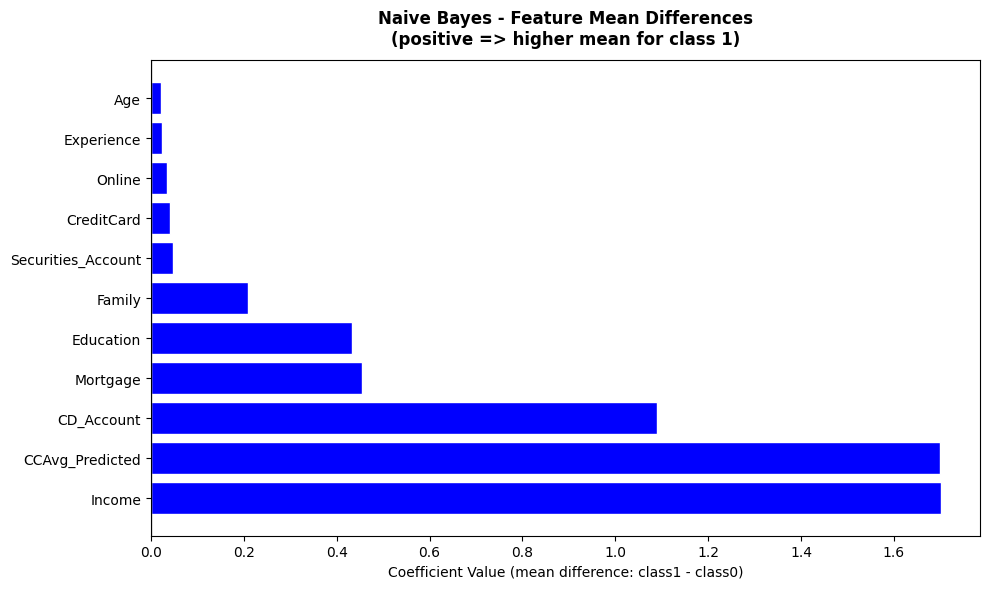

In [261]:
if hasattr(navie_bayes_model, "theta_") and navie_bayes_model.theta_.shape[0] >= 2:
    coef_values = navie_bayes_model.theta_[1] - navie_bayes_model.theta_[0]
else:
    coef_values = np.zeros(len(X_clf.columns))

coef_df = pd.DataFrame({
    'Feature': X_clf.columns,
    'Coefficient': coef_values
}).sort_values(by='Coefficient', ascending=False)
print(coef_df.to_string(index=False))
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['blue' if coef > 0 else 'orange' for coef in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(x=0, color='gray', lw=1)
ax.set_xlabel('Coefficient Value (mean difference: class1 - class0)')
ax.set_title('Naive Bayes - Feature Mean Differences\n(positive => higher mean for class 1)', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

Decision Tree

In [262]:
tree = DecisionTreeClassifier(max_depth=4,min_samples_leaf=10 ,random_state=35)
tree.fit(X_train_clf_scaled, y_train_clf)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",35
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

Tree Classification Predictions

In [263]:
y_pred_test_clf = tree.predict(X_test_clf_scaled)
y_pred_train_clf = tree.predict(X_train_clf_scaled)
y_pred_test_proba_clf = tree.predict_proba(X_test_clf_scaled)[:, 1]
y_pred_train_proba_clf = tree.predict_proba(X_train_clf_scaled)[:, 1]

Tree Test Confusion Matrix

Confusion Matrix:
 TN - correctly predicted negatives (predicted as 0, actual as 0): 1350
 FP - incorrectly predicted positives (predicted as 1, actual as 0): 6
 FN - incorrectly predicted negatives (predicted as 0, actual as 1): 25
 TP - correctly predicted positives (predicted as 1, actual as 1): 119


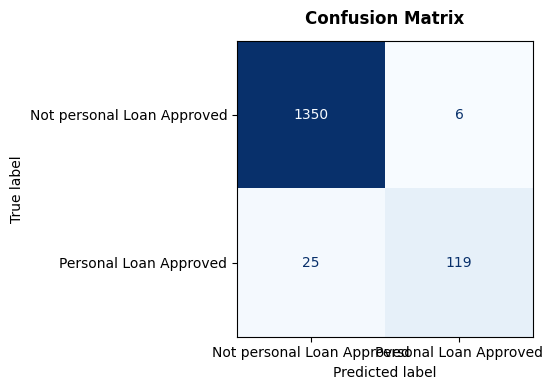

In [264]:
cm = confusion_matrix(y_test_clf, y_pred_test_clf)
tn, fp, fn, tp = cm.ravel()
print("Confusion Matrix:")
print(f' TN - correctly predicted negatives (predicted as 0, actual as 0): {tn}')
print(f' FP - incorrectly predicted positives (predicted as 1, actual as 0): {fp}')
print(f' FN - incorrectly predicted negatives (predicted as 0, actual as 1): {fn}')
print(f' TP - correctly predicted positives (predicted as 1, actual as 1): {tp}')
fig, ax = plt.subplots(figsize=(6, 4))
display = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                 display_labels=['Not personal Loan Approved', 'Personal Loan Approved'])
display.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
ax.set_title('Confusion Matrix',fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

Tree Train Confusion Matrix

Training Confusion Matrix:
 TN - correctly predicted negatives (predicted as 0, actual as 0): 3157
 FP - incorrectly predicted positives (predicted as 1, actual as 0): 7
 FN - incorrectly predicted negatives (predicted as 0, actual as 1): 53
 TP - correctly predicted positives (predicted as 1, actual as 1): 283


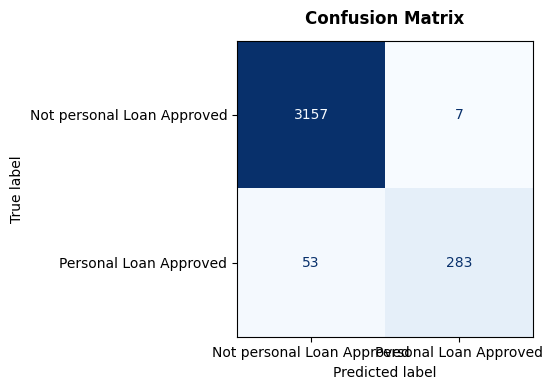

In [265]:
cm_train = confusion_matrix(y_train_clf, y_pred_train_clf)
tn_train, fp_train, fn_train, tp_train = cm_train.ravel()
print("Training Confusion Matrix:")
print(f' TN - correctly predicted negatives (predicted as 0, actual as 0): {tn_train}')
print(f' FP - incorrectly predicted positives (predicted as 1, actual as 0): {fp_train}')
print(f' FN - incorrectly predicted negatives (predicted as 0, actual as 1): {fn_train}')
print(f' TP - correctly predicted positives (predicted as 1, actual as 1): {tp_train}')
fig, ax = plt.subplots(figsize=(6, 4))
display = ConfusionMatrixDisplay(confusion_matrix=cm_train, 
                                 display_labels=['Not personal Loan Approved', 'Personal Loan Approved'])
display.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
ax.set_title('Confusion Matrix',fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

Calculate Train and Test Metrics

In [266]:
train_accuracy = accuracy_score(y_train_clf, y_pred_train_clf)
test_accuracy = accuracy_score(y_test_clf, y_pred_test_clf)
train_precision = precision_score(y_train_clf, y_pred_train_clf)
test_precision = precision_score(y_test_clf, y_pred_test_clf)
train_recall = recall_score(y_train_clf, y_pred_train_clf)
test_recall = recall_score(y_test_clf, y_pred_test_clf)
train_f1 = f1_score(y_train_clf, y_pred_train_clf)
test_f1 = f1_score(y_test_clf, y_pred_test_clf)
test_auc = roc_auc_score(y_test_clf, y_pred_test_proba_clf)
train_auc = roc_auc_score(y_train_clf, y_pred_train_proba_clf)

print("======== Training Metrics ========")
print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Training Precision: {train_precision:.2f}")
print(f"Training Recall: {train_recall:.2f}")
print(f"Training F1-Score: {train_f1:.2f}")
print(f"Training AUC-ROC: {train_auc:.2f}")

print("\n======== Testing Metrics ========")
print(f"Testing Accuracy: {test_accuracy:.2f}")
print(f"Testing Precision: {test_precision:.2f}")
print(f"Testing Recall: {test_recall:.2f}")
print(f"Testing F1-Score: {test_f1:.2f}")
print(f"Testing AUC-ROC: {test_auc:.2f}")

======== Training Metrics ========
Training Accuracy: 0.98
Training Precision: 0.98
Training Recall: 0.84
Training F1-Score: 0.90
Training AUC-ROC: 0.99

======== Testing Metrics ========
Testing Accuracy: 0.98
Testing Precision: 0.95
Testing Recall: 0.83
Testing F1-Score: 0.88
Testing AUC-ROC: 0.97


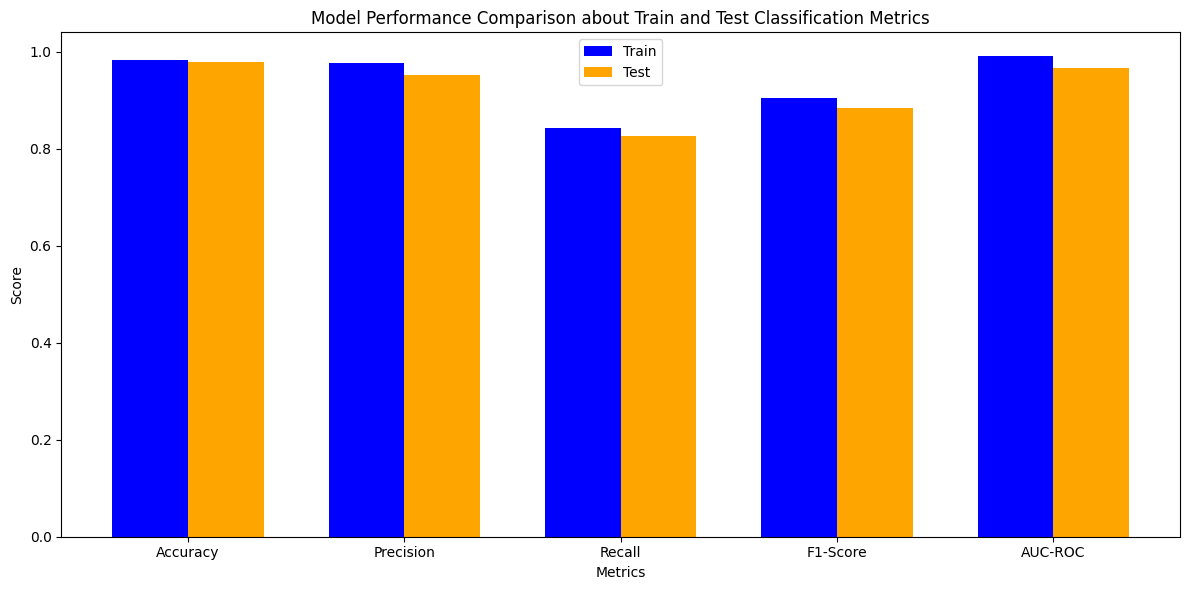

In [267]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
train_values = [train_accuracy, train_precision, train_recall, train_f1, train_auc]
test_values = [test_accuracy, test_precision, test_recall, test_f1, test_auc]
x = np.arange(len(metrics))
width = 0.35
plt.figure(figsize=(12, 6))
plt.bar(x - width/2, train_values, width, label='Train', color='blue')
plt.bar(x + width/2, test_values, width, label='Test', color='orange')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison about Train and Test Classification Metrics')
plt.xticks(x, metrics)
plt.legend()
plt.tight_layout()
plt.show()

ROC Curve & AUC Test

C:\Users\parth\AppData\Local\Temp\ipykernel_32728\1198257529.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([0, 1], [0, 1],'k--', color='red', lw=2, label='Random Classifier')


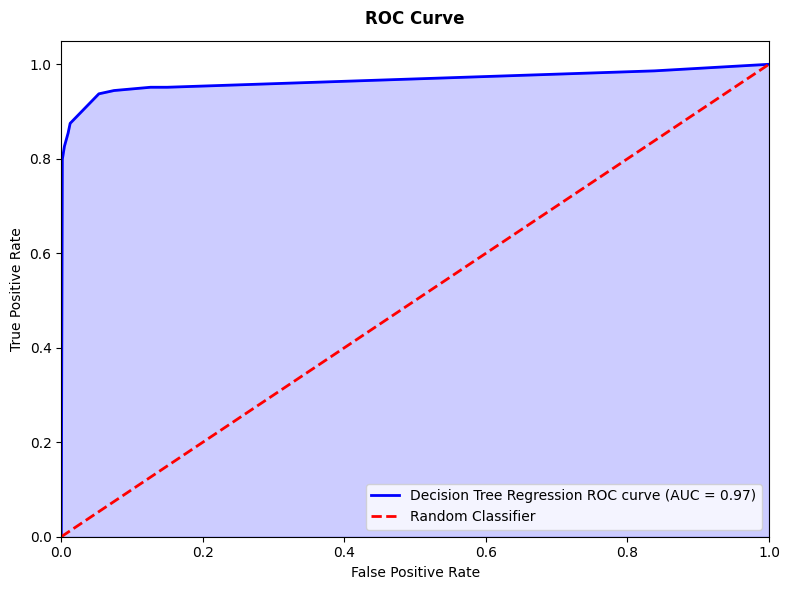

In [268]:
fpr, tpr, thresholds = roc_curve(y_test_clf, y_pred_test_proba_clf)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='blue', lw=2,label=f'Decision Tree Regression ROC curve (AUC = {test_auc:.2f})')
ax.plot([0, 1], [0, 1],'k--', color='red', lw=2, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.2, color='blue')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve',fontweight='bold', pad=12)
ax.legend(loc='lower right')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

ROC Curve & AUC Train

C:\Users\parth\AppData\Local\Temp\ipykernel_32728\3668378487.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([0, 1], [0, 1],'k--', color='red', lw=2, label='Random Classifier')


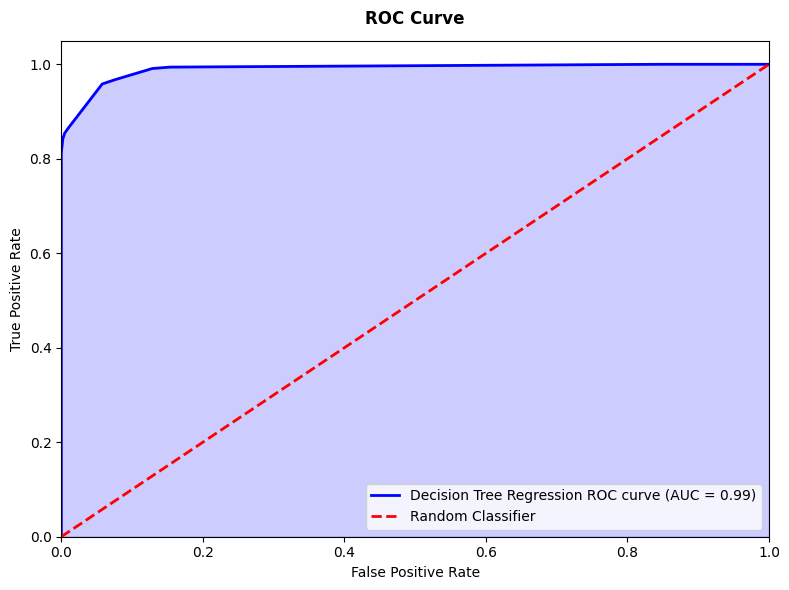

In [269]:
fpr, tpr, thresholds = roc_curve(y_train_clf, y_pred_train_proba_clf)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='blue', lw=2,label=f'Decision Tree Regression ROC curve (AUC = {train_auc:.2f})')
ax.plot([0, 1], [0, 1],'k--', color='red', lw=2, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.2, color='blue')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve',fontweight='bold', pad=12)
ax.legend(loc='lower right')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

Precision VS Recall - Threshold Tuning -Test

 Threshold |   Accuracy |  Precision |     Recall |   F1-Score
--------------------------------------------------------------
      0.30 |       0.98 |       0.90 |       0.85 |       0.88 
      0.40 |       0.98 |       0.95 |       0.83 |       0.88 
      0.50 |       0.98 |       0.95 |       0.83 |       0.88  <-- Default
      0.60 |       0.98 |       0.98 |       0.80 |       0.88 
      0.70 |       0.98 |       0.98 |       0.80 |       0.88 


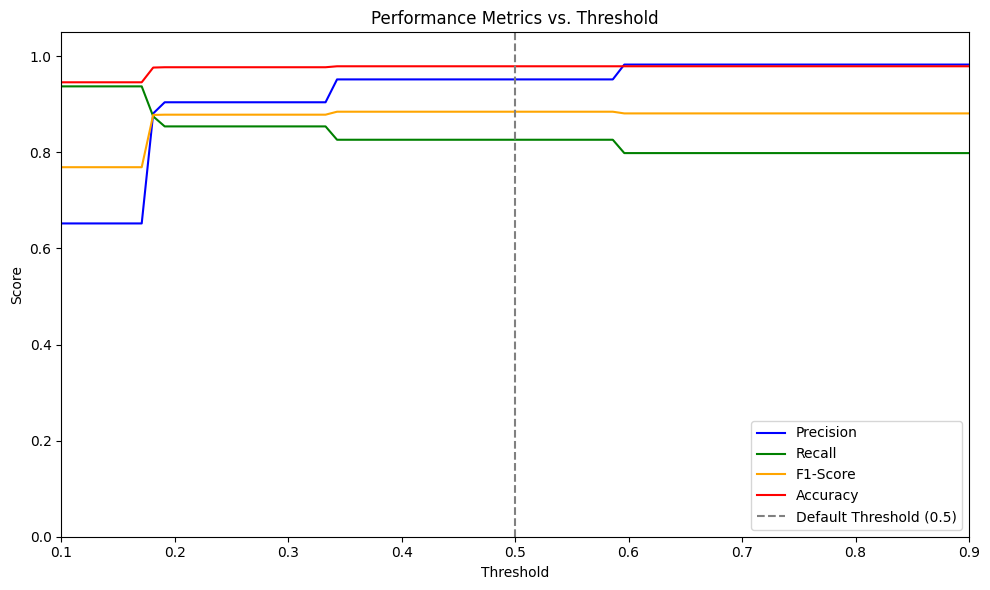

In [270]:
thresholds_to_try = [0.3,0.4,0.5,0.6,0.7]
print(f"{'Threshold':>10} | {'Accuracy':>10} | {'Precision':>10} | {'Recall':>10} | {'F1-Score':>10}")
print("-" * 62)
for threshold in thresholds_to_try:
    y_pred_threshold = (y_pred_test_proba_clf >= threshold).astype(int)
    acc = accuracy_score(y_test_clf, y_pred_threshold)
    prec = precision_score(y_test_clf, y_pred_threshold)
    rec = recall_score(y_test_clf, y_pred_threshold)
    f1 = f1_score(y_test_clf, y_pred_threshold)
    marker = " <-- Default" if threshold == 0.5 else ""
    print(f"{threshold:>10.2f} | {acc:>10.2f} | {prec:>10.2f} | {rec:>10.2f} | {f1:>10.2f} {marker}")
thresh_range = np.linspace(0.1, 0.9, 80)
precisions, recalls, f1s, accuracies = [], [], [], []
for thresh in thresh_range:
    y_pred_thresh = (y_pred_test_proba_clf >= thresh).astype(int)
    precisions.append(precision_score(y_test_clf, y_pred_thresh))
    recalls.append(recall_score(y_test_clf, y_pred_thresh))
    f1s.append(f1_score(y_test_clf, y_pred_thresh))
    accuracies.append(accuracy_score(y_test_clf, y_pred_thresh))
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresh_range, precisions, label='Precision', color='blue')
ax.plot(thresh_range, recalls, label='Recall', color='green')
ax.plot(thresh_range, f1s, label='F1-Score', color='orange')
ax.plot(thresh_range, accuracies, label='Accuracy', color='red')
ax.axvline(x=0.5, color='gray', linestyle='--', label='Default Threshold (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Performance Metrics vs. Threshold')
ax.legend(loc='lower right')
ax.set_xlim([0.1, 0.9])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

Precision VS Recall - Threshold Tuning -Train

 Threshold |   Accuracy |  Precision |     Recall |   F1-Score
--------------------------------------------------------------
      0.30 |       0.98 |       0.95 |       0.85 |       0.90 
      0.40 |       0.98 |       0.98 |       0.84 |       0.90 
      0.50 |       0.98 |       0.98 |       0.84 |       0.90  <-- Default
      0.60 |       0.98 |       1.00 |       0.81 |       0.90 
      0.70 |       0.98 |       1.00 |       0.81 |       0.90 


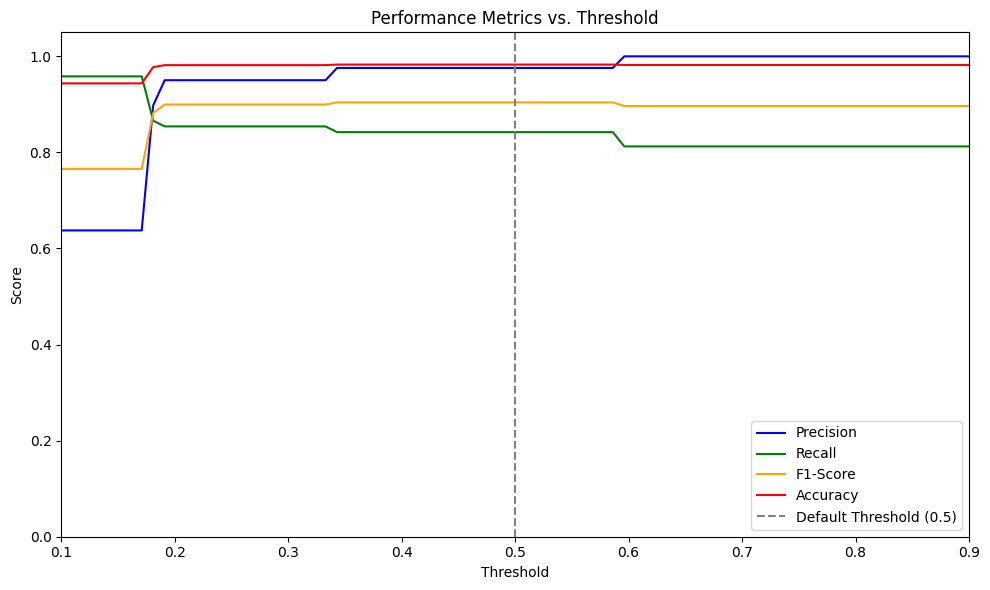

In [271]:
train_thresholds_to_try = [0.3,0.4,0.5,0.6,0.7]
print(f"{'Threshold':>10} | {'Accuracy':>10} | {'Precision':>10} | {'Recall':>10} | {'F1-Score':>10}")
print("-" * 62)
for threshold in train_thresholds_to_try:
    y_pred_threshold_train = (y_pred_train_proba_clf >= threshold).astype(int)
    acc_train = accuracy_score(y_train_clf, y_pred_threshold_train)
    prec_train = precision_score(y_train_clf, y_pred_threshold_train)
    rec_train = recall_score(y_train_clf, y_pred_threshold_train)
    f1_train = f1_score(y_train_clf, y_pred_threshold_train)
    marker = " <-- Default" if threshold == 0.5 else ""
    print(f"{threshold:>10.2f} | {acc_train:>10.2f} | {prec_train:>10.2f} | {rec_train:>10.2f} | {f1_train:>10.2f} {marker}")
thresh_range_train = np.linspace(0.1, 0.9, 80)
precisions_train, recalls_train, f1s_train, accuracies_train = [], [], [], []
for thresh in thresh_range_train:
    y_pred_thresh_train = (y_pred_train_proba_clf >= thresh).astype(int)
    precisions_train.append(precision_score(y_train_clf, y_pred_thresh_train))
    recalls_train.append(recall_score(y_train_clf, y_pred_thresh_train))
    f1s_train.append(f1_score(y_train_clf, y_pred_thresh_train))
    accuracies_train.append(accuracy_score(y_train_clf, y_pred_thresh_train))
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresh_range_train, precisions_train, label='Precision', color='blue')
ax.plot(thresh_range_train, recalls_train, label='Recall', color='green')
ax.plot(thresh_range_train, f1s_train, label='F1-Score', color='orange')
ax.plot(thresh_range_train, accuracies_train, label='Accuracy', color='red')
ax.axvline(x=0.5, color='gray', linestyle='--', label='Default Threshold (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Performance Metrics vs. Threshold')
ax.legend(loc='lower right')
ax.set_xlim([0.1, 0.9])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

           Feature  Coefficient
         Education     0.439074
            Income     0.325569
            Family     0.177147
   CCAvg_Predicted     0.042967
        CD_Account     0.008615
        Experience     0.006587
               Age     0.000041
Securities_Account     0.000000
          Mortgage     0.000000
            Online     0.000000
        CreditCard     0.000000


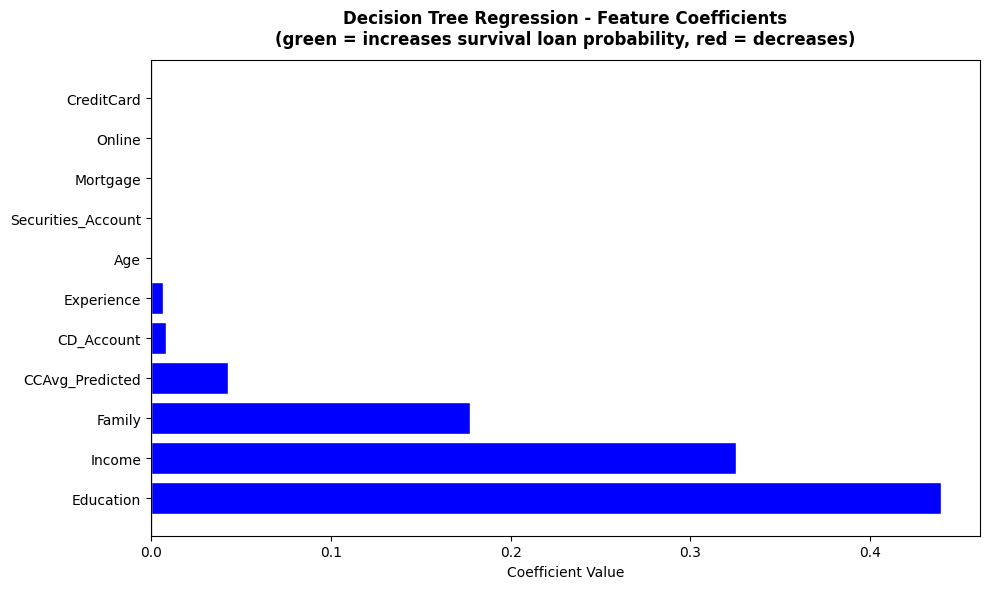

In [272]:
coef_df = pd.DataFrame({
    'Feature': X_clf.columns,
    'Coefficient': tree.feature_importances_
}).sort_values(by='Coefficient', ascending=False)
print(coef_df.to_string(index=False))
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['blue' if coef > 0 else 'orange' for coef in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(x=0, color='gray', lw=1)
ax.set_xlabel('Coefficient Value')
ax.set_title('Decision Tree Regression - Feature Coefficients\n''(green = increases survival loan probability, red = decreases)',fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

Random Forest

In [273]:
random_Forest = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=35)
random_Forest.fit(X_train_clf_scaled, y_train_clf)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

Classification Predictions

In [274]:
y_pred_test_clf = random_Forest.predict(X_test_clf_scaled)
y_pred_train_clf = random_Forest.predict(X_train_clf_scaled)
y_pred_test_proba_clf = random_Forest.predict_proba(X_test_clf_scaled)[:, 1]
y_pred_train_proba_clf = random_Forest.predict_proba(X_train_clf_scaled)[:, 1]

Test Confusion Matrix

Confusion Matrix:
 TN - correctly predicted negatives (predicted as 0, actual as 0): 1356
 FP - incorrectly predicted positives (predicted as 1, actual as 0): 0
 FN - incorrectly predicted negatives (predicted as 0, actual as 1): 32
 TP - correctly predicted positives (predicted as 1, actual as 1): 112


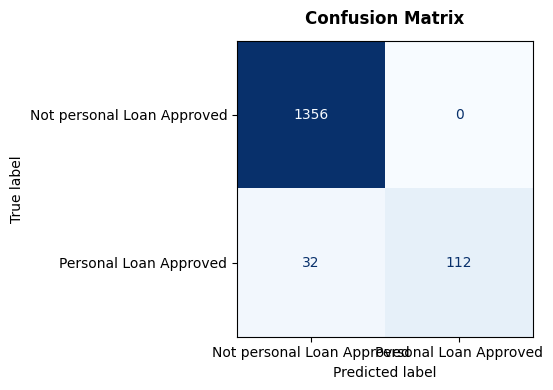

In [275]:
cm = confusion_matrix(y_test_clf, y_pred_test_clf)
tn, fp, fn, tp = cm.ravel()
print("Confusion Matrix:")
print(f' TN - correctly predicted negatives (predicted as 0, actual as 0): {tn}')
print(f' FP - incorrectly predicted positives (predicted as 1, actual as 0): {fp}')
print(f' FN - incorrectly predicted negatives (predicted as 0, actual as 1): {fn}')
print(f' TP - correctly predicted positives (predicted as 1, actual as 1): {tp}')
fig, ax = plt.subplots(figsize=(6, 4))
display = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                 display_labels=['Not personal Loan Approved', 'Personal Loan Approved'])
display.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
ax.set_title('Confusion Matrix',fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


Train Confusion Matrix

Training Confusion Matrix:
 TN - correctly predicted negatives (predicted as 0, actual as 0): 3164
 FP - incorrectly predicted positives (predicted as 1, actual as 0): 0
 FN - incorrectly predicted negatives (predicted as 0, actual as 1): 66
 TP - correctly predicted positives (predicted as 1, actual as 1): 270


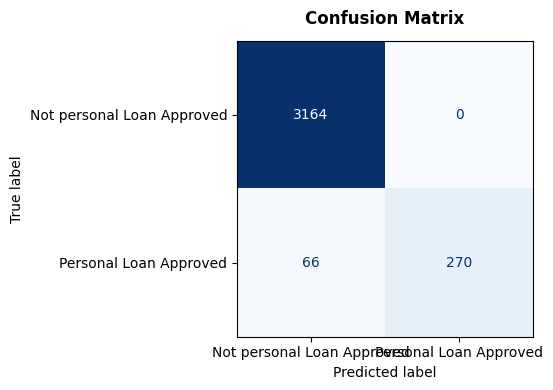

In [276]:
cm_train = confusion_matrix(y_train_clf, y_pred_train_clf)
tn_train, fp_train, fn_train, tp_train = cm_train.ravel()
print("Training Confusion Matrix:")
print(f' TN - correctly predicted negatives (predicted as 0, actual as 0): {tn_train}')
print(f' FP - incorrectly predicted positives (predicted as 1, actual as 0): {fp_train}')
print(f' FN - incorrectly predicted negatives (predicted as 0, actual as 1): {fn_train}')
print(f' TP - correctly predicted positives (predicted as 1, actual as 1): {tp_train}')
fig, ax = plt.subplots(figsize=(6, 4))
display = ConfusionMatrixDisplay(confusion_matrix=cm_train, 
                                 display_labels=['Not personal Loan Approved', 'Personal Loan Approved'])
display.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
ax.set_title('Confusion Matrix',fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

Calculate Train and Test Metrics

In [277]:
train_accuracy = accuracy_score(y_train_clf, y_pred_train_clf)
test_accuracy = accuracy_score(y_test_clf, y_pred_test_clf)
train_precision = precision_score(y_train_clf, y_pred_train_clf)
test_precision = precision_score(y_test_clf, y_pred_test_clf)
train_recall = recall_score(y_train_clf, y_pred_train_clf)
test_recall = recall_score(y_test_clf, y_pred_test_clf)
train_f1 = f1_score(y_train_clf, y_pred_train_clf)
test_f1 = f1_score(y_test_clf, y_pred_test_clf)
test_auc = roc_auc_score(y_test_clf, y_pred_test_proba_clf)
train_auc = roc_auc_score(y_train_clf, y_pred_train_proba_clf)

print("======== Training Metrics ========")
print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Training Precision: {train_precision:.2f}")
print(f"Training Recall: {train_recall:.2f}")
print(f"Training F1-Score: {train_f1:.2f}")
print(f"Training AUC-ROC: {train_auc:.2f}")

print("\n======== Testing Metrics ========")
print(f"Testing Accuracy: {test_accuracy:.2f}")
print(f"Testing Precision: {test_precision:.2f}")
print(f"Testing Recall: {test_recall:.2f}")
print(f"Testing F1-Score: {test_f1:.2f}")
print(f"Testing AUC-ROC: {test_auc:.2f}")

======== Training Metrics ========
Training Accuracy: 0.98
Training Precision: 1.00
Training Recall: 0.80
Training F1-Score: 0.89
Training AUC-ROC: 0.98

======== Testing Metrics ========
Testing Accuracy: 0.98
Testing Precision: 1.00
Testing Recall: 0.78
Testing F1-Score: 0.88
Testing AUC-ROC: 0.97


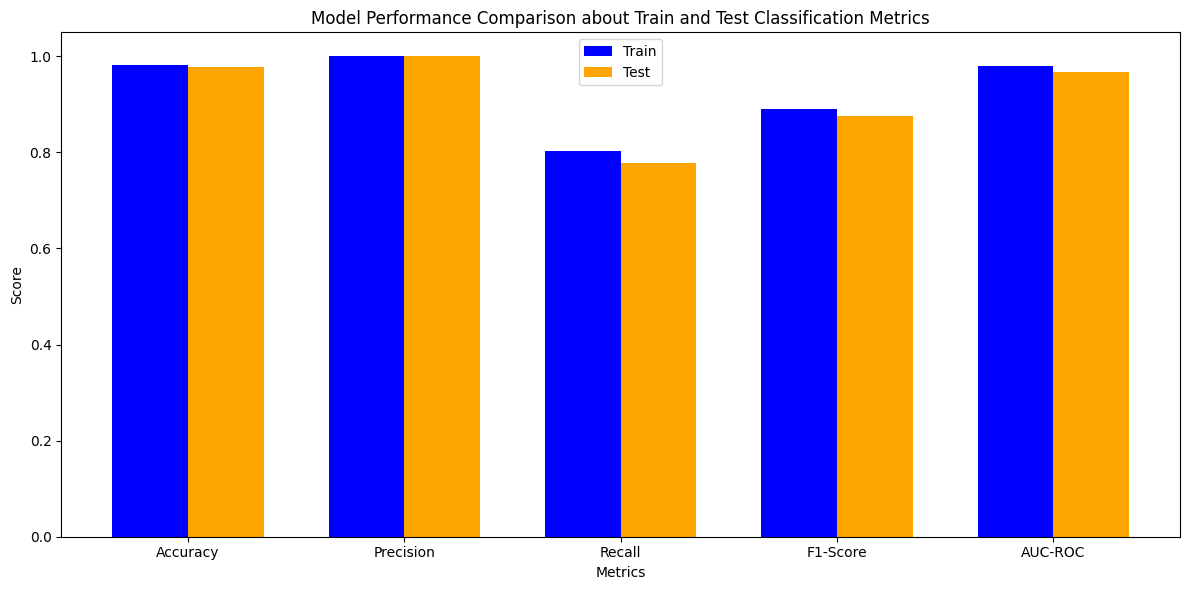

In [278]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
train_values = [train_accuracy, train_precision, train_recall, train_f1, train_auc]
test_values = [test_accuracy, test_precision, test_recall, test_f1, test_auc]
x = np.arange(len(metrics))
width = 0.35
plt.figure(figsize=(12, 6))
plt.bar(x - width/2, train_values, width, label='Train', color='blue')
plt.bar(x + width/2, test_values, width, label='Test', color='orange')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison about Train and Test Classification Metrics')
plt.xticks(x, metrics)
plt.legend()
plt.tight_layout()
plt.show()

ROC Curve & AUC Test

C:\Users\parth\AppData\Local\Temp\ipykernel_32728\1752641286.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([0, 1], [0, 1],'k--', color='red', lw=2, label='Random Classifier')


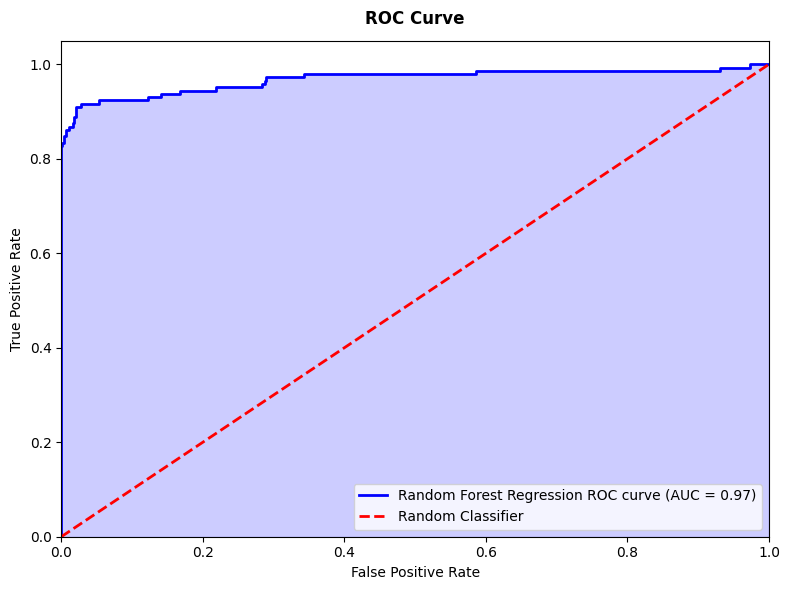

In [279]:
fpr, tpr, thresholds = roc_curve(y_test_clf, y_pred_test_proba_clf)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='blue', lw=2,label=f'Random Forest Regression ROC curve (AUC = {test_auc:.2f})')
ax.plot([0, 1], [0, 1],'k--', color='red', lw=2, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.2, color='blue')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve',fontweight='bold', pad=12)
ax.legend(loc='lower right')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

ROC Curve & AUC Train

C:\Users\parth\AppData\Local\Temp\ipykernel_32728\3228535525.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([0, 1], [0, 1],'k--', color='red', lw=2, label='Random Classifier')


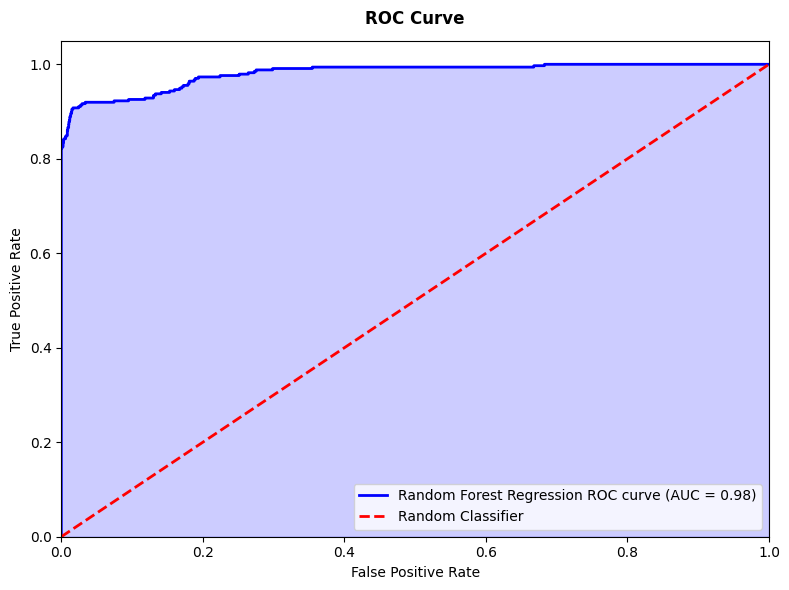

In [280]:
fpr, tpr, thresholds = roc_curve(y_train_clf, y_pred_train_proba_clf)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='blue', lw=2,label=f'Random Forest Regression ROC curve (AUC = {train_auc:.2f})')
ax.plot([0, 1], [0, 1],'k--', color='red', lw=2, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.2, color='blue')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve',fontweight='bold', pad=12)
ax.legend(loc='lower right')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

Precision VS Recall - Threshold Tuning

 Threshold |   Accuracy |  Precision |     Recall |   F1-Score
--------------------------------------------------------------
      0.30 |       0.98 |       0.91 |       0.86 |       0.88 
      0.40 |       0.98 |       0.98 |       0.83 |       0.90 
      0.50 |       0.98 |       1.00 |       0.78 |       0.88  <-- Default
      0.60 |       0.96 |       1.00 |       0.60 |       0.75 
      0.70 |       0.94 |       1.00 |       0.40 |       0.57 


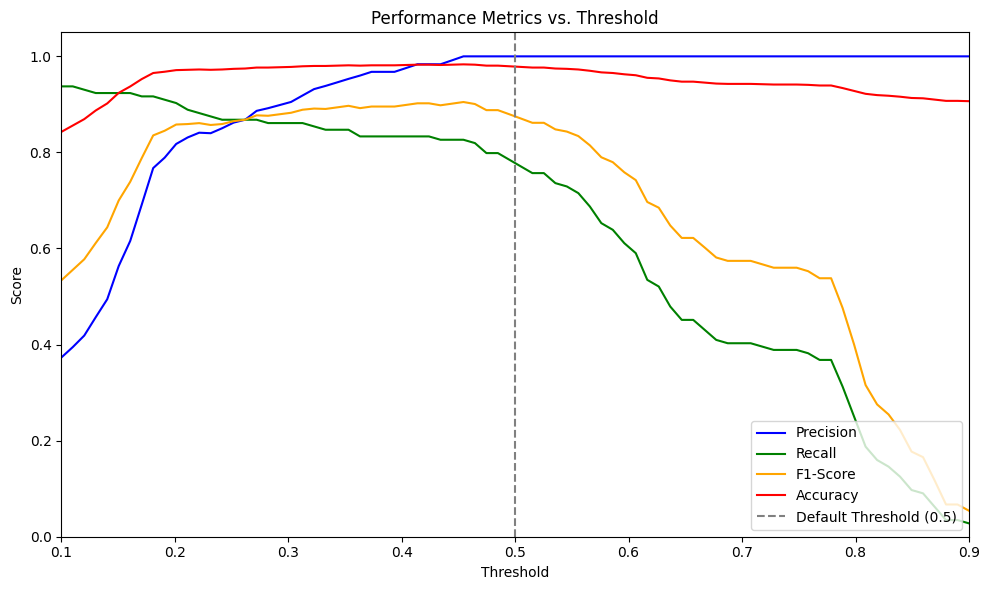

In [281]:
thresholds_to_try = [0.3,0.4,0.5,0.6,0.7]
print(f"{'Threshold':>10} | {'Accuracy':>10} | {'Precision':>10} | {'Recall':>10} | {'F1-Score':>10}")
print("-" * 62)
for threshold in thresholds_to_try:
    y_pred_threshold = (y_pred_test_proba_clf >= threshold).astype(int)
    acc = accuracy_score(y_test_clf, y_pred_threshold)
    prec = precision_score(y_test_clf, y_pred_threshold)
    rec = recall_score(y_test_clf, y_pred_threshold)
    f1 = f1_score(y_test_clf, y_pred_threshold)
    marker = " <-- Default" if threshold == 0.5 else ""
    print(f"{threshold:>10.2f} | {acc:>10.2f} | {prec:>10.2f} | {rec:>10.2f} | {f1:>10.2f} {marker}")
thresh_range = np.linspace(0.1, 0.9, 80)
precisions, recalls, f1s, accuracies = [], [], [], []
for thresh in thresh_range:
    y_pred_thresh = (y_pred_test_proba_clf >= thresh).astype(int)
    precisions.append(precision_score(y_test_clf, y_pred_thresh))
    recalls.append(recall_score(y_test_clf, y_pred_thresh))
    f1s.append(f1_score(y_test_clf, y_pred_thresh))
    accuracies.append(accuracy_score(y_test_clf, y_pred_thresh))
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresh_range, precisions, label='Precision', color='blue')
ax.plot(thresh_range, recalls, label='Recall', color='green')
ax.plot(thresh_range, f1s, label='F1-Score', color='orange')
ax.plot(thresh_range, accuracies, label='Accuracy', color='red')
ax.axvline(x=0.5, color='gray', linestyle='--', label='Default Threshold (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Performance Metrics vs. Threshold')
ax.legend(loc='lower right')
ax.set_xlim([0.1, 0.9])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

Precision VS Recall - Threshold Tuning -Train

 Threshold |   Accuracy |  Precision |     Recall |   F1-Score
--------------------------------------------------------------
      0.30 |       0.98 |       0.93 |       0.85 |       0.89 
      0.40 |       0.98 |       1.00 |       0.82 |       0.90 
      0.50 |       0.98 |       1.00 |       0.80 |       0.89  <-- Default
      0.60 |       0.96 |       1.00 |       0.62 |       0.77 
      0.70 |       0.94 |       1.00 |       0.41 |       0.58 


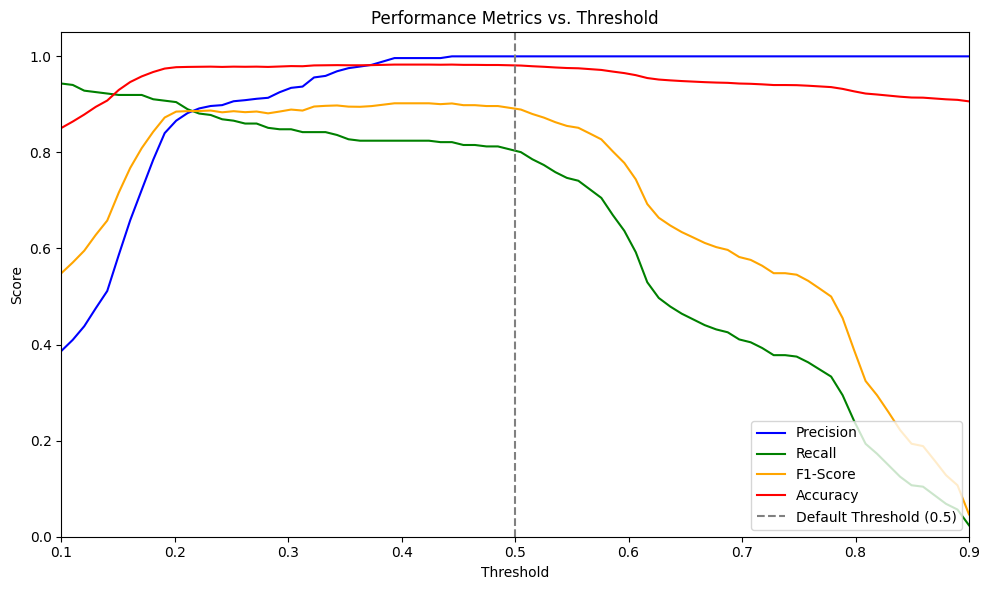

In [282]:
train_thresholds_to_try = [0.3,0.4,0.5,0.6,0.7]
print(f"{'Threshold':>10} | {'Accuracy':>10} | {'Precision':>10} | {'Recall':>10} | {'F1-Score':>10}")
print("-" * 62)
for threshold in train_thresholds_to_try:
    y_pred_threshold_train = (y_pred_train_proba_clf >= threshold).astype(int)
    acc_train = accuracy_score(y_train_clf, y_pred_threshold_train)
    prec_train = precision_score(y_train_clf, y_pred_threshold_train)
    rec_train = recall_score(y_train_clf, y_pred_threshold_train)
    f1_train = f1_score(y_train_clf, y_pred_threshold_train)
    marker = " <-- Default" if threshold == 0.5 else ""
    print(f"{threshold:>10.2f} | {acc_train:>10.2f} | {prec_train:>10.2f} | {rec_train:>10.2f} | {f1_train:>10.2f} {marker}")
thresh_range_train = np.linspace(0.1, 0.9, 80)
precisions_train, recalls_train, f1s_train, accuracies_train = [], [], [], []
for thresh in thresh_range_train:
    y_pred_thresh_train = (y_pred_train_proba_clf >= thresh).astype(int)
    precisions_train.append(precision_score(y_train_clf, y_pred_thresh_train))
    recalls_train.append(recall_score(y_train_clf, y_pred_thresh_train))
    f1s_train.append(f1_score(y_train_clf, y_pred_thresh_train))
    accuracies_train.append(accuracy_score(y_train_clf, y_pred_thresh_train))
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresh_range_train, precisions_train, label='Precision', color='blue')
ax.plot(thresh_range_train, recalls_train, label='Recall', color='green')
ax.plot(thresh_range_train, f1s_train, label='F1-Score', color='orange')
ax.plot(thresh_range_train, accuracies_train, label='Accuracy', color='red')
ax.axvline(x=0.5, color='gray', linestyle='--', label='Default Threshold (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Performance Metrics vs. Threshold')
ax.legend(loc='lower right')
ax.set_xlim([0.1, 0.9])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

           Feature  Coefficient
   CCAvg_Predicted     0.306391
            Income     0.260521
         Education     0.170534
            Family     0.114591
        CD_Account     0.086352
          Mortgage     0.035080
               Age     0.010326
        Experience     0.008910
        CreditCard     0.003951
Securities_Account     0.002113
            Online     0.001231


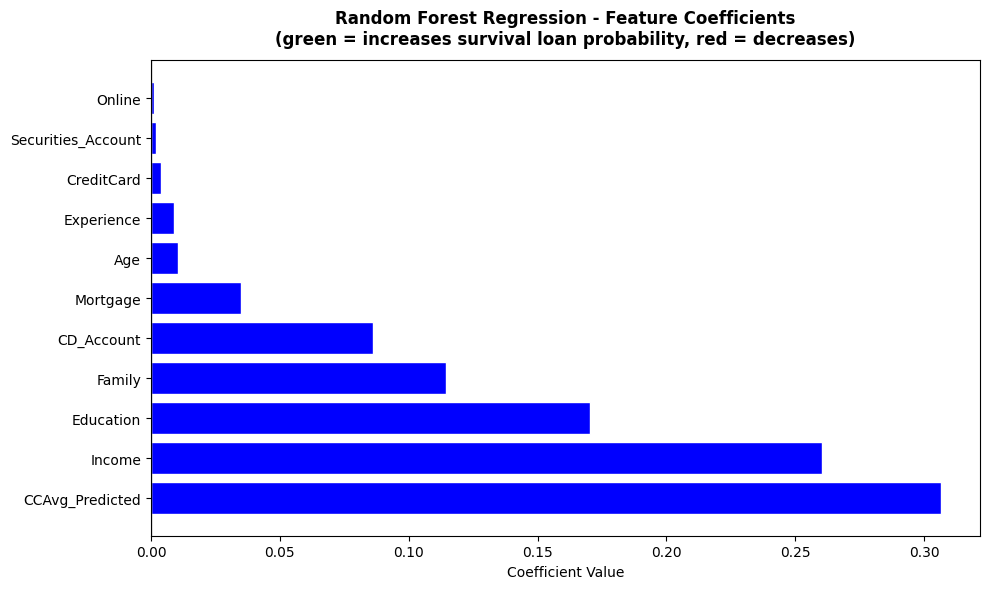

In [ ]:
coef_df = pd.DataFrame({
    'Feature': X_clf.columns,
    'Coefficient': random_Forest.feature_importances_
}).sort_values(by='Coefficient', ascending=False)
print(coef_df.to_string(index=False))
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['blue' if coef > 0 else 'orange' for coef in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(x=0, color='gray', lw=1)
ax.set_xlabel('Coefficient Value')
ax.set_title('Random Forest Regression - Feature Coefficients\n''(green = increases survival loan probability, red = decreases)',fontweight='bold', pad=12)
plt.tight_layout()
plt.show() 